#  Sports Multi-Object Detection & Persistent ID Tracking
**Stack:** YOLOv8 · ByteTrack · OpenCV

**Self-contained notebook** — just run each cell top to bottom. No external files needed.

---
**Video source used:** [youtube_soccer_match]('https://www.youtube.com/watch?v=vuCTH7jjPnw')

You can swap in any public sports video via the `VIDEO_URL` variable in Cell 2.

## Cell 1 — Install dependencies

In [12]:
!pip install ultralytics opencv-python yt-dlp pandas matplotlib seaborn tqdm pyyaml -q
print('Dependencies ready')

Dependencies ready



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 2 — Configuration (edit here)

In [13]:
import os

# ── Video source ─────────────────────────────────────────────────────────────
# Public soccer match 
VIDEO_URL  = 'https://www.youtube.com/watch?v=vuCTH7jjPnw'
VIDEO_PATH = 'input_videos'

# ── Model & detection ────────────────────────────────────────────────────────
MODEL_NAME     = 'yolov8m.pt'
CONF_THRESHOLD = 0.35         
IOU_THRESHOLD  = 0.45         
CLASSES        = [0]           
IMG_SIZE       = 640           
DEVICE         = 'cpu'    

# ── Tracking ─────────────────────────────────────────────────────────────────
TRACKER_TYPE      = 'bytetrack.yaml'
TRACK_HIGH_THRESH = 0.5
TRACK_LOW_THRESH  = 0.1
NEW_TRACK_THRESH  = 0.6
TRACK_BUFFER      = 30  
MATCH_THRESH      = 0.8

# ── Processing ───────────────────────────────────────────────────────────────
EVERY_N    = 1      
MAX_FRAMES = None   

# ── Visualisation ────────────────────────────────────────────────────────────
DRAW_TRAJECTORIES  = True
TRAJECTORY_LENGTH  = 60    
DRAW_HEATMAP       = True
HEATMAP_ALPHA      = 0.60

# Colour palette (BGR)
PALETTE = [
    (255, 56, 56),  (255,157, 51), (255,247, 51),  ( 51,255, 51),
    ( 51,255,255),  ( 51,148,255), (148, 51,255),  (255, 51,255),
    (255,153,153),  (153,255,153), (153,153,255),  (255,228,153),
    (153,255,228),  (228,153,255), (255,200,100),  (100,255,200),
    (200,100,255),  (255,100,200), (100,200,255),  (200,255,100),
]

# ── Output ───────────────────────────────────────────────────────────────────
OUT_DIR           = 'outputs'
ANNOTATED_VIDEO   = f'{OUT_DIR}/annotated_output.mp4'
HEATMAP_IMG       = f'{OUT_DIR}/heatmap.png'
TRAJECTORY_IMG    = f'{OUT_DIR}/trajectories.png'
TOPVIEW_IMG       = f'{OUT_DIR}/topview.png'
COUNT_CSV         = f'{OUT_DIR}/object_count_over_time.csv'
ANALYSIS_PLOT     = f'{OUT_DIR}/analysis_plots.png'
SAMPLE_DETECT_IMG = f'{OUT_DIR}/sample_detection.png'

os.makedirs(OUT_DIR, exist_ok=True)
print('Config ready')

Config ready


## Cell 3 — Download the video

In [16]:
import subprocess, sys, os

if os.path.exists(VIDEO_PATH) and os.path.getsize(VIDEO_PATH) > 0:
    print(f'Video already exists: {VIDEO_PATH}')
else:
    print(f' Downloading: {VIDEO_URL}')
    
    result = subprocess.run([
        sys.executable, "-m", "yt_dlp",   
        VIDEO_URL,
        "-f", "best[ext=mp4]",         
        "-o", VIDEO_PATH,
        "--no-playlist"
    ])

    if result.returncode != 0:
        print(" Download failed")
        sys.exit()
import cv2
cap = cv2.VideoCapture(VIDEO_PATH)
W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS = cap.get(cv2.CAP_PROP_FPS) or 30.0
N   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()
print(f'\n Video ready: {W}×{H} @ {FPS:.1f} fps | {N} frames ({N/FPS:.0f}s)')        

 Downloading: https://www.youtube.com/watch?v=vuCTH7jjPnw

 Video ready: 640×360 @ 25.0 fps | 375 frames (15s)


## Cell 4 — Load YOLOv8 model

In [17]:
from ultralytics import YOLO

model = YOLO(MODEL_NAME)
CLASS_NAMES = model.names
print(f' Model loaded: {MODEL_NAME}')
print(f'   Tracking class: {CLASS_NAMES[0]}')

 Model loaded: yolov8m.pt
   Tracking class: person


## Cell 5 — Single-frame detection sanity check

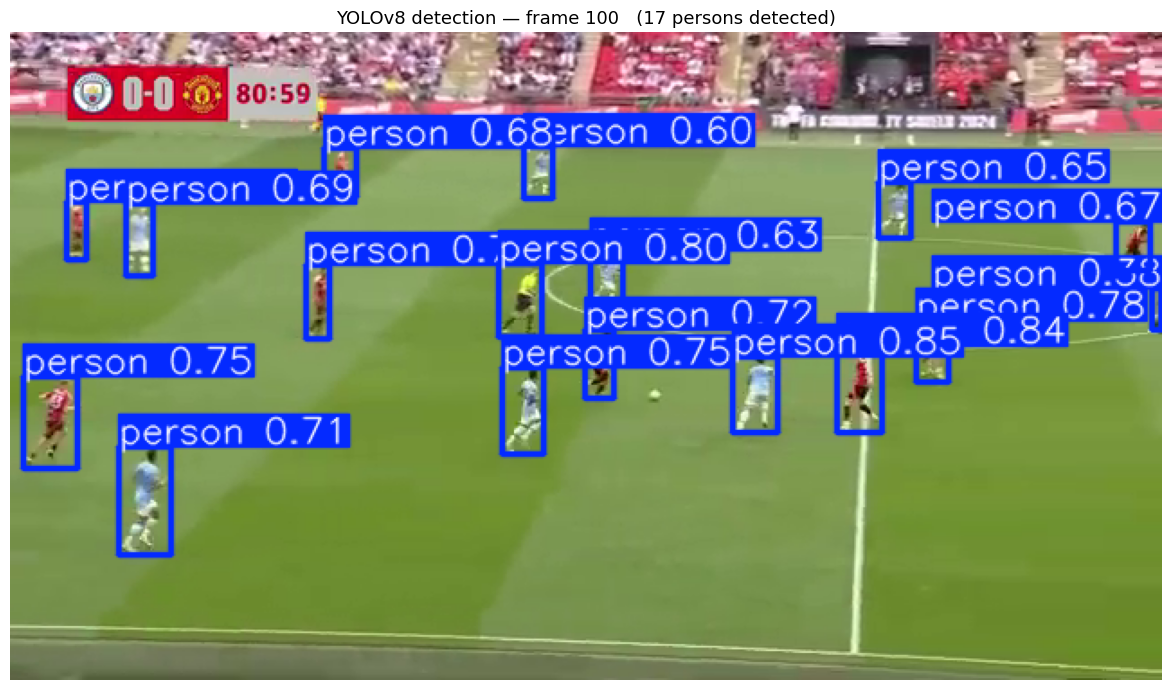

Saved → outputs/sample_detection.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Grab frame #100
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, min(100, N - 1))
ok, sample_frame = cap.read()
cap.release()

results = model.predict(sample_frame, conf=CONF_THRESHOLD,
                        classes=CLASSES, verbose=False)
annotated = results[0].plot()

plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'YOLOv8 detection — frame 100   ({len(results[0].boxes)} persons detected)',
          fontsize=13)
plt.tight_layout()
plt.savefig(SAMPLE_DETECT_IMG, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved → {SAMPLE_DETECT_IMG}')

## Cell 6 — Helper functions
All visualisation and utility logic defined inline.

In [19]:
from collections import defaultdict, deque
import time

# ── Colour helper ─────────────────────────────────────────────────────────────
def id_color(track_id):
    return PALETTE[track_id % len(PALETTE)]

# ── Draw bounding box + ID label ──────────────────────────────────────────────
def draw_box(frame, x1, y1, x2, y2, track_id, label, conf):
    x1,y1,x2,y2 = int(x1),int(y1),int(x2),int(y2)
    color = id_color(track_id)

    # semi-transparent fill
    overlay = frame.copy()
    cv2.rectangle(overlay, (x1,y1), (x2,y2), color, -1)
    cv2.addWeighted(overlay, 0.10, frame, 0.90, 0, frame)

    # border
    cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)

    # label pill
    text = f'ID:{track_id}  {conf:.2f}'
    (tw,th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
    pad = 4
    lx1, ly1, lx2, ly2 = x1, max(0, y1-th-2*pad), x1+tw+2*pad, y1
    cv2.rectangle(frame, (lx1,ly1), (lx2,ly2), color, -1)
    cv2.putText(frame, text, (lx1+pad, ly2-pad),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 2, cv2.LINE_AA)

# ── Draw trajectory tail ──────────────────────────────────────────────────────
def draw_trajectory(frame, points, color, max_len=60):
    pts = list(points)[-max_len:]
    n   = len(pts)
    for i in range(1, n):
        alpha = i / n
        faded = tuple(int(c * alpha) for c in color)
        cv2.line(frame, pts[i-1], pts[i], faded, 2, cv2.LINE_AA)
    if pts:
        cv2.circle(frame, pts[-1], 4, color, -1, cv2.LINE_AA)

# ── Draw count HUD ────────────────────────────────────────────────────────────
def draw_hud(frame, count, frame_idx, total):
    cv2.rectangle(frame, (8,8), (270,64), (20,20,20), -1)
    cv2.rectangle(frame, (8,8), (270,64), (200,200,200), 1)
    cv2.putText(frame, f'Active subjects: {count}', (16,36),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2, cv2.LINE_AA)
    progress = frame_idx / max(total-1, 1)
    cv2.rectangle(frame, (12,48), (258,58), (60,60,60), -1)
    cv2.rectangle(frame, (12,48), (12+int(246*progress),58), (0,200,0), -1)

# ── Build heatmap ─────────────────────────────────────────────────────────────
def add_to_heatmap(heat, fx, fy, radius=20):
    cv2.circle(heat, (int(fx), int(fy)), radius, 1.0, -1)

def render_heatmap(heat, background=None, alpha=0.6):
    norm = cv2.normalize(heat, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    coloured = cv2.applyColorMap(norm, cv2.COLORMAP_JET)
    if background is not None:
        bg = cv2.resize(background, (heat.shape[1], heat.shape[0]))
        return cv2.addWeighted(bg, 1-alpha, coloured, alpha, 0)
    return coloured

# ── Bird's-eye top view ───────────────────────────────────────────────────────
def build_topview(all_trajectories, frame_size, canvas_size=(600,400)):
    fW,fH = frame_size
    cW,cH = canvas_size
    canvas = np.full((cH,cW,3), 30, dtype=np.uint8)
    sx,sy  = cW/fW, cH/fH
    for tid, pts in all_trajectories.items():
        color   = id_color(tid)
        scaled  = [(int(x*sx), int(y*sy)) for x,y in pts]
        for i in range(1, len(scaled)):
            cv2.line(canvas, scaled[i-1], scaled[i], color, 1, cv2.LINE_AA)
        if scaled:
            cv2.circle(canvas, scaled[-1], 4, color, -1)
    cv2.rectangle(canvas, (0,0), (cW-1,cH-1), (180,180,180), 1)
    cv2.putText(canvas, "Bird's-eye — all trajectories",
                (8,18), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)
    return canvas

print(' Helper functions defined')

 Helper functions defined


## Cell 7 — Full tracking pipeline

In [20]:
from tqdm.notebook import tqdm
import csv

# ── Output video writer ───────────────────────────────────────────────────────
out_fps = FPS / EVERY_N
fourcc  = cv2.VideoWriter_fourcc(*'mp4v')
writer  = cv2.VideoWriter(ANNOTATED_VIDEO, fourcc, out_fps, (W, H))
assert writer.isOpened(), 'VideoWriter failed to open'

# ── State ─────────────────────────────────────────────────────────────────────
trajectory_history = defaultdict(lambda: deque(maxlen=TRACK_BUFFER * 2))
heat_acc           = np.zeros((H, W), dtype=np.float32)
traj_canvas        = np.zeros((H, W, 3), dtype=np.uint8)
count_rows         = []
first_frame        = None

# ── Frame loop ────────────────────────────────────────────────────────────────
cap         = cv2.VideoCapture(VIDEO_PATH)
frame_idx   = 0
processed   = 0
pbar        = tqdm(total=MAX_FRAMES or N, desc='Tracking', unit='fr')

while True:
    ok, frame = cap.read()
    if not ok:
        break

    if frame_idx % EVERY_N != 0:
        frame_idx += 1
        continue

    if first_frame is None:
        first_frame = frame.copy()

    # ── Detection + ByteTrack ─────────────────────────────────────────────────
    results = model.track(
        source   = frame,
        persist  = True,           
        tracker  = TRACKER_TYPE,
        conf     = CONF_THRESHOLD,
        iou      = IOU_THRESHOLD,
        classes  = CLASSES,
        imgsz    = IMG_SIZE,
        device   = DEVICE,
        verbose  = False,
    )

    out_frame = frame.copy()
    active_count = 0

    for result in results:
        boxes = result.boxes
        if boxes is None or boxes.id is None:
            continue

        ids   = boxes.id.int().tolist()
        xyxys = boxes.xyxy.tolist()
        confs = boxes.conf.tolist()
        clss  = boxes.cls.int().tolist()

        # Draw trajectory tails first (so boxes appear on top)
        if DRAW_TRAJECTORIES:
            for tid in ids:
                pts = trajectory_history[tid]
                draw_trajectory(out_frame, pts, id_color(tid), TRAJECTORY_LENGTH)
                draw_trajectory(traj_canvas, pts, id_color(tid), TRAJECTORY_LENGTH)

        for tid, xyxy, conf, cls in zip(ids, xyxys, confs, clss):
            x1,y1,x2,y2 = xyxy
            cx = int((x1+x2)/2)
            cy = int((y1+y2)/2)
            fy = int(y2)         
            fx = cx

            # Update trajectory
            trajectory_history[tid].append((cx, cy))

            # Heatmap
            if DRAW_HEATMAP:
                add_to_heatmap(heat_acc, fx, fy)

            # Draw box
            draw_box(out_frame, x1, y1, x2, y2, tid,
                     CLASS_NAMES.get(cls, str(cls)), conf)
            active_count += 1

    # HUD
    draw_hud(out_frame, active_count, frame_idx, N)

    writer.write(out_frame)
    count_rows.append({'frame': frame_idx,
                       'time_s': round(frame_idx / FPS, 3),
                       'count': active_count})

    frame_idx += 1
    processed += 1
    pbar.update(1)

    if MAX_FRAMES and processed >= MAX_FRAMES:
        break

cap.release()
writer.release()
pbar.close()

print(f'\n Annotated video saved → {ANNOTATED_VIDEO}')
print(f'   Total unique IDs assigned: {len(trajectory_history)}')

Tracking:   0%|          | 0/375 [00:00<?, ?fr/s]


 Annotated video saved → outputs/annotated_output.mp4
   Total unique IDs assigned: 51


## Cell 8 — Save post-processed outputs

In [21]:
# Heatmap
heatmap = render_heatmap(heat_acc, background=first_frame, alpha=HEATMAP_ALPHA)
cv2.imwrite(HEATMAP_IMG, heatmap)
print(f' Heatmap → {HEATMAP_IMG}')

# Trajectory overlay
dark_bg  = (first_frame * 0.25).astype(np.uint8)
traj_out = cv2.addWeighted(dark_bg, 0.5, traj_canvas, 0.8, 0)
cv2.imwrite(TRAJECTORY_IMG, traj_out)
print(f' Trajectory image → {TRAJECTORY_IMG}')

# Bird's-eye top view
tv = build_topview(trajectory_history, (W, H))
cv2.imwrite(TOPVIEW_IMG, tv)
print(f' Top-view → {TOPVIEW_IMG}')

# Count CSV
import csv
with open(COUNT_CSV, 'w', newline='') as f:
    writer_csv = csv.DictWriter(f, fieldnames=['frame','time_s','count'])
    writer_csv.writeheader()
    writer_csv.writerows(count_rows)
print(f' Count CSV → {COUNT_CSV}')

 Heatmap → outputs/heatmap.png
 Trajectory image → outputs/trajectories.png
 Top-view → outputs/topview.png
 Count CSV → outputs/object_count_over_time.csv


## Cell 9 — Analysis plots

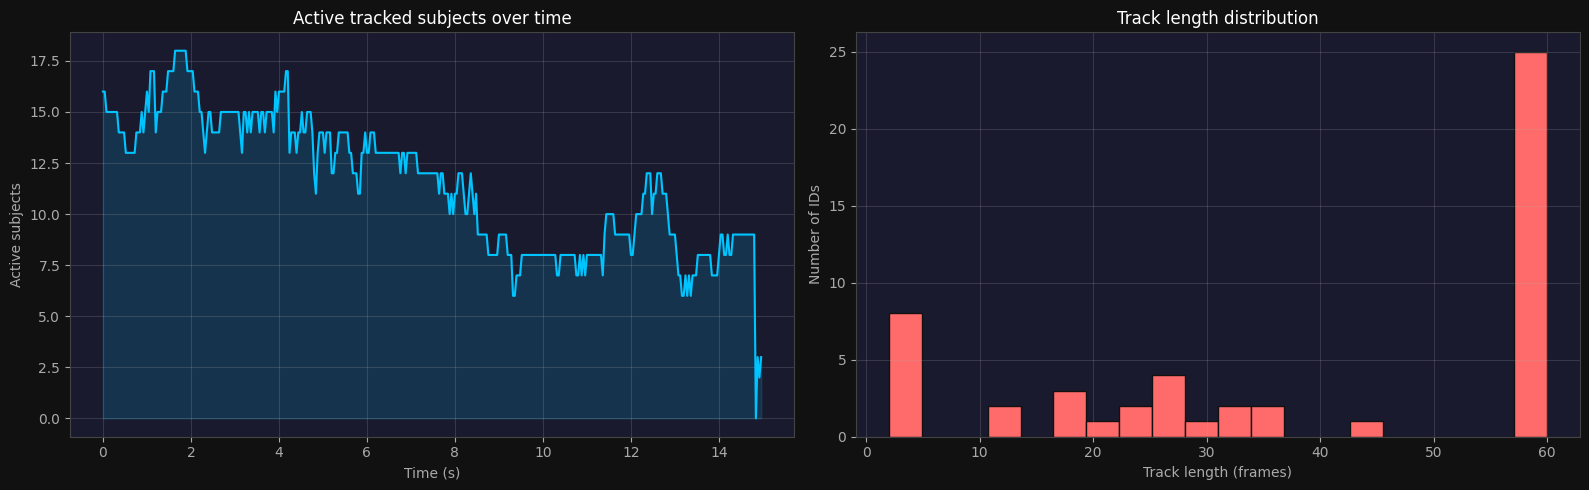


 Statistics
  Total unique IDs : 51
  Mean track len   : 39.0 frames
  Max track len    : 60 frames
  Peak count       : 18 subjects
  Mean count       : 11.5 subjects


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(count_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#111111')
for ax in axes:
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='#aaaaaa')
    ax.spines[:].set_color('#444')

# Count over time
axes[0].plot(df['time_s'], df['count'], color='#00c4ff', linewidth=1.5)
axes[0].fill_between(df['time_s'], df['count'], alpha=0.15, color='#00c4ff')
axes[0].set_xlabel('Time (s)', color='#aaa')
axes[0].set_ylabel('Active subjects', color='#aaa')
axes[0].set_title('Active tracked subjects over time', color='white')
axes[0].grid(True, alpha=0.2)

# Track length distribution
lengths = [len(v) for v in trajectory_history.values()]
axes[1].hist(lengths, bins=20, color='#ff6b6b', edgecolor='#111')
axes[1].set_xlabel('Track length (frames)', color='#aaa')
axes[1].set_ylabel('Number of IDs', color='#aaa')
axes[1].set_title('Track length distribution', color='white')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(ANALYSIS_PLOT, dpi=120, bbox_inches='tight', facecolor='#111111')
plt.show()

print(f'\n Statistics')
print(f'  Total unique IDs : {len(lengths)}')
print(f'  Mean track len   : {sum(lengths)/len(lengths):.1f} frames')
print(f'  Max track len    : {max(lengths)} frames')
print(f'  Peak count       : {df["count"].max()} subjects')
print(f'  Mean count       : {df["count"].mean():.1f} subjects')

## Cell 10 — Display all output images inline


 Sample detection (frame 100)


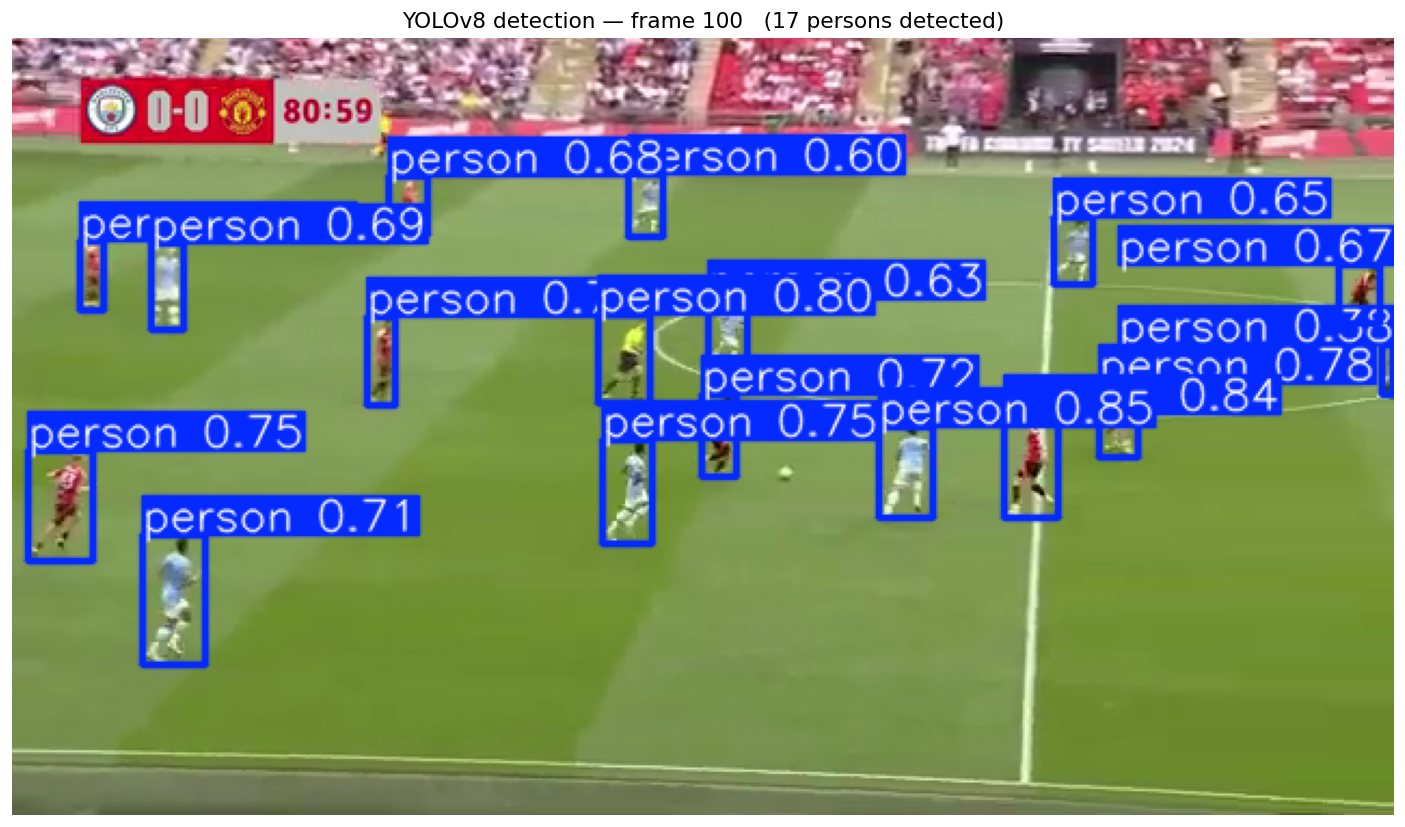


  Movement heatmap


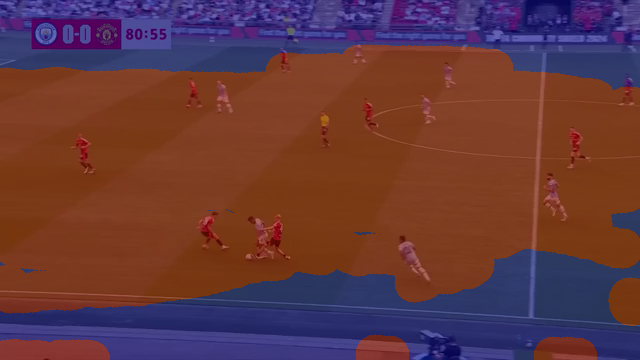


 Trajectory overlay


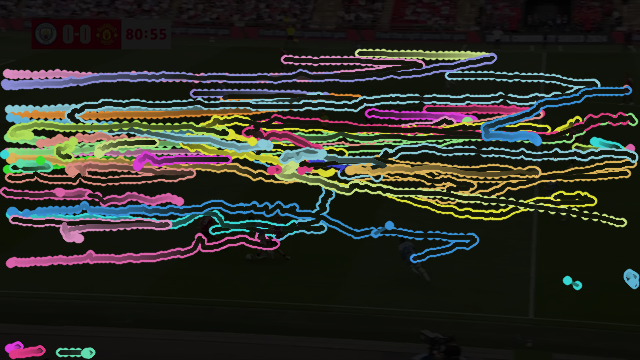


  Bird's-eye top view


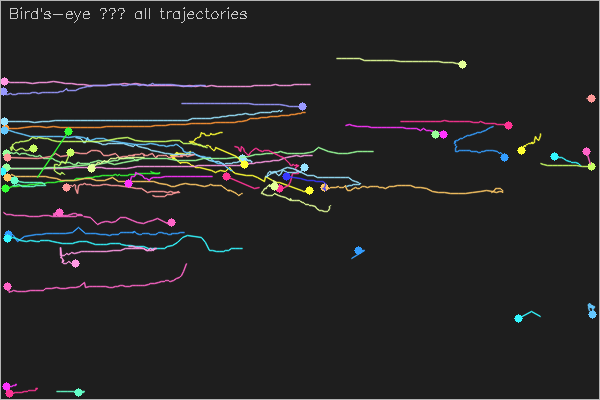


 Analysis plots


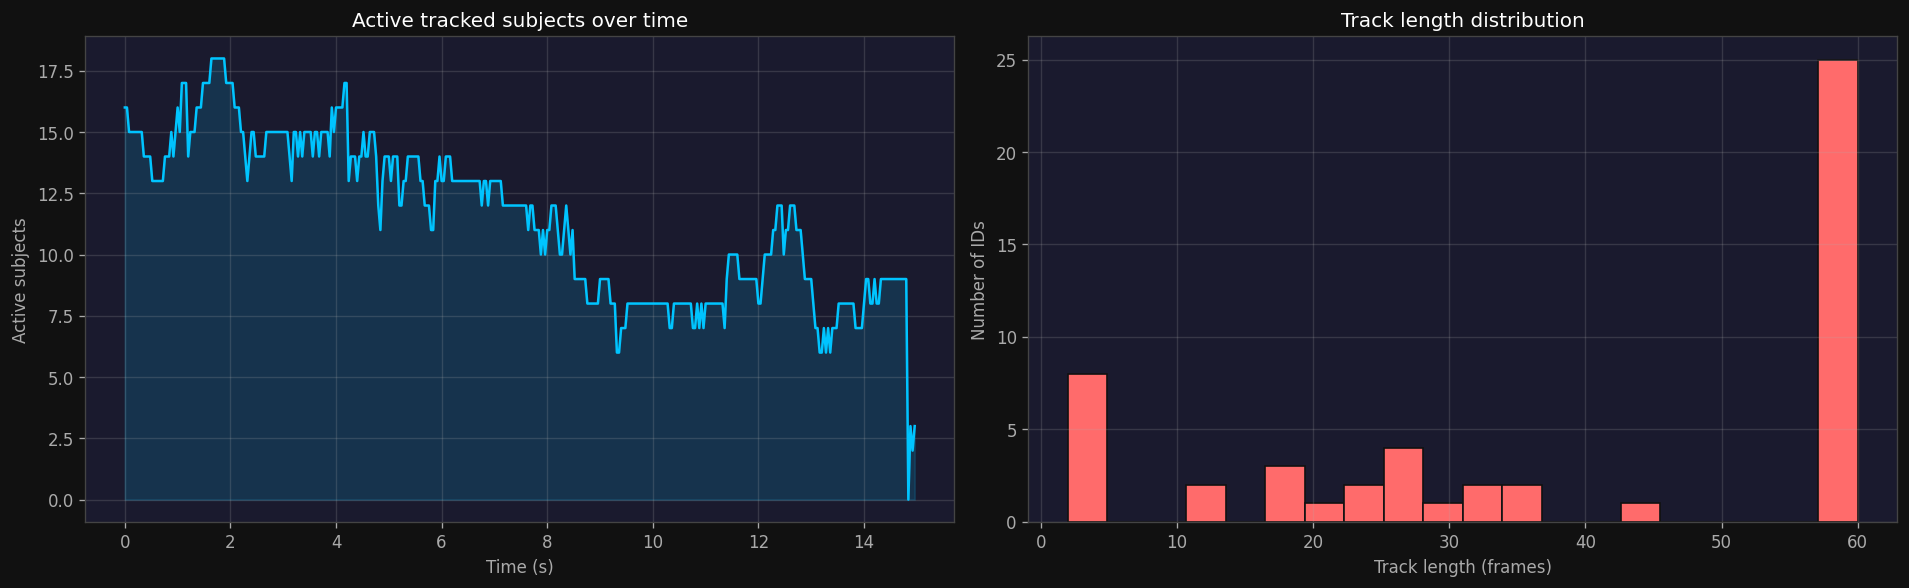

In [23]:
from IPython.display import Image as IPImage, display

for path, title in [
    (SAMPLE_DETECT_IMG, ' Sample detection (frame 100)'),
    (HEATMAP_IMG,       '  Movement heatmap'),
    (TRAJECTORY_IMG,    ' Trajectory overlay'),
    (TOPVIEW_IMG,       '  Bird\'s-eye top view'),
    (ANALYSIS_PLOT,     ' Analysis plots'),
]:
    if os.path.exists(path):
        print(f'\n{title}')
        display(IPImage(path, width=900))
    else:
        print(f'[not found] {path}')